
# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

__year_resale_value    36
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Power_perf_factor       2
dtype: int64


<Axes: >

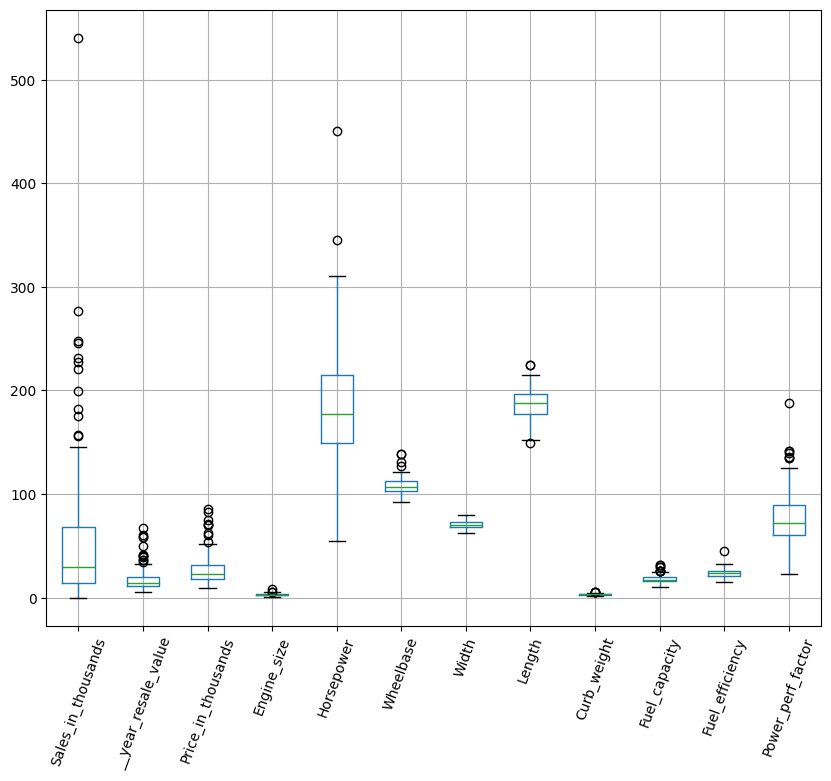

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Car_sales.csv', sep = ',')
null_values = df.isnull().sum()
null_values = null_values[null_values > 0]
print(null_values)
fig, axes = plt.subplots(figsize=(10, 8))
df.boxplot(ax = axes, rot = 70)

In [16]:
for i in null_values.index:
    df[i] = df[i].fillna(df[i].median())
df.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64

In [18]:
df = df[df['Sales_in_thousands'].between(0, 150)]
df = df[df['__year_resale_value'].between(0, 40)]
df = df[df['Price_in_thousands'].between(0, 70)]
df = df[df['Horsepower'].between(0, 320)]
df = df[df['Power_perf_factor'].between(0, 130)]

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

In [19]:
df.dtypes

Manufacturer               str
Model                      str
Sales_in_thousands     float64
__year_resale_value    float64
Vehicle_type               str
Price_in_thousands     float64
Engine_size            float64
Horsepower             float64
Wheelbase              float64
Width                  float64
Length                 float64
Curb_weight            float64
Fuel_capacity          float64
Fuel_efficiency        float64
Latest_Launch              str
Power_perf_factor      float64
dtype: object

In [22]:
numeric_df = df.select_dtypes(include='float64') 
numeric_df

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
0,16.919,16.360,21.500,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,58.280150
1,39.384,19.875,28.400,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,91.370778
2,14.114,18.225,22.799,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,72.030917
3,8.588,29.725,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,91.389779
4,20.397,22.255,23.990,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...
152,3.545,14.180,24.400,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,66.498812
153,15.245,14.180,27.500,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,70.654495
154,17.531,14.180,28.800,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,71.155978
155,3.493,14.180,45.500,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,101.623357


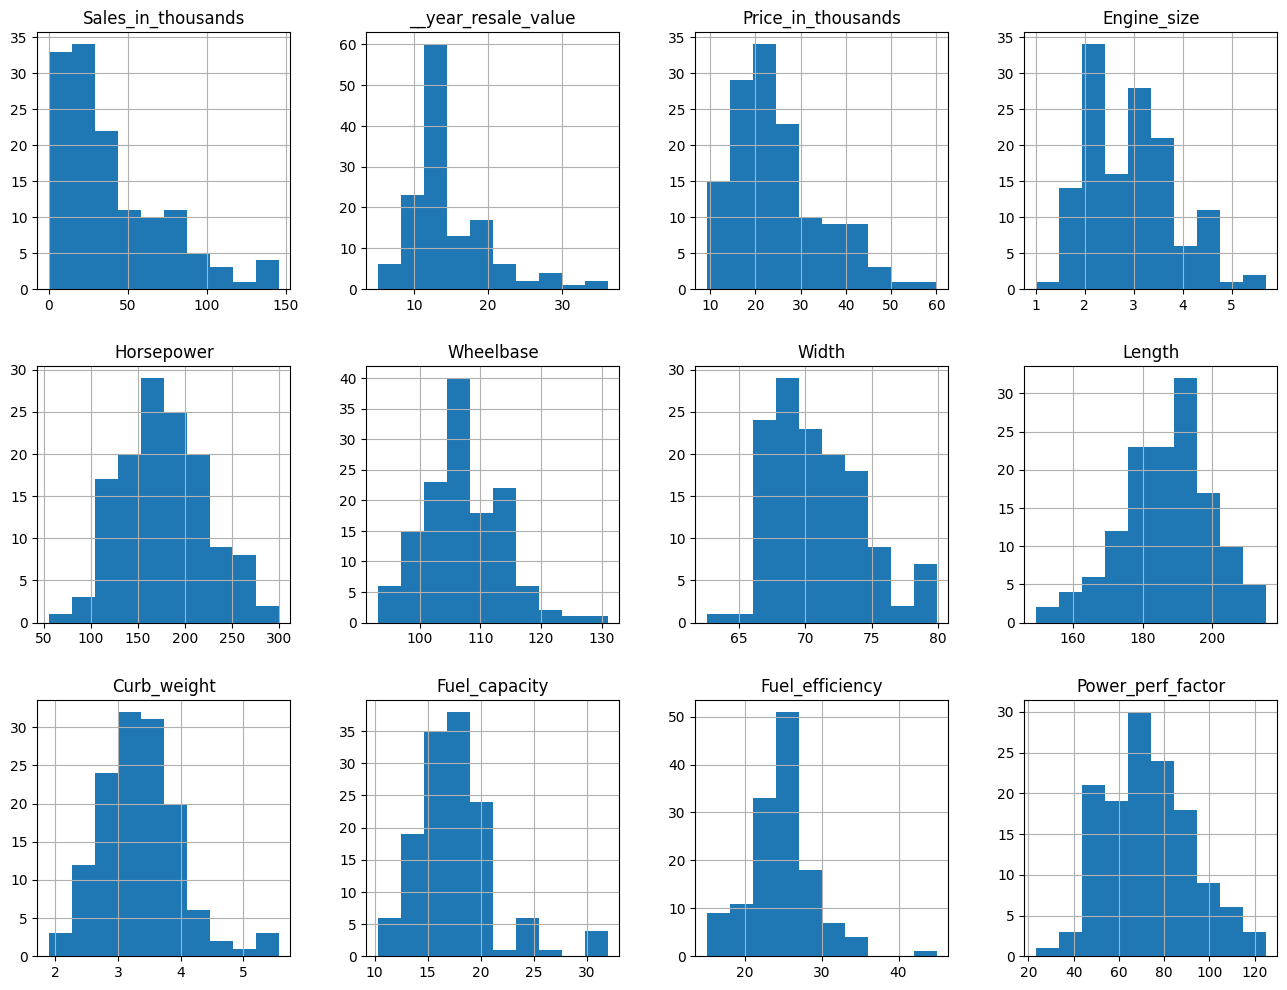

In [44]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(numeric_df.columns):
    df.hist(feature, ax=axes[idx // 4, idx % 4])

<Axes: >

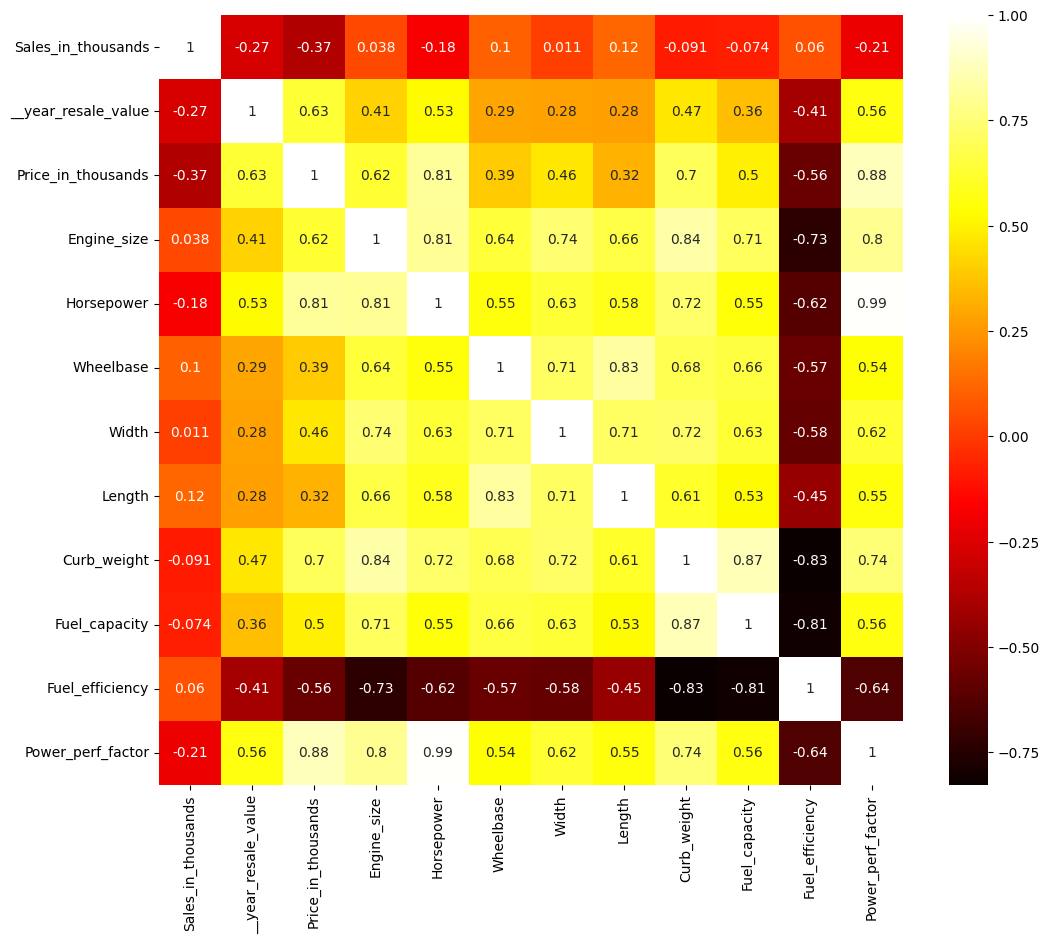

In [46]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='hot')

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [57]:
from sklearn.model_selection import train_test_split
X = numeric_df.iloc[:, 0:-1]
y = numeric_df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [91]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error

alpha = np.logspace(-4, 4, 50)
print('Значения alpha для всех видов моделей:', [f'{a:.2e}' for a in alpha], '\n\n\n')

# БАЗОВАЯ МОДЕЛЬ
base_model = LinearRegression()
base_model.fit(X_train, y_train)


# RIDGE МОДЕЛЬ
param_grid_ridge = {'alpha': np.logspace(-4, 4, 50)}
grid_search_ridge = GridSearchCV(Ridge(), param_grid=param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge.fit(X_train, y_train)

# LASSO МОДЕЛЬ
param_random_lasso = {'alpha': np.logspace(-4, 4, 50)}
random_search_lasso = RandomizedSearchCV(Lasso(), param_distributions=param_random_lasso, cv=5, scoring='neg_mean_squared_error')
random_search_lasso.fit(X_train, y_train)

# ELASTIC_NET МОДЕЛЬ
param_random_elastic = {'alpha': np.logspace(-4, 4, 50), "l1_ratio": np.linspace(0, 1, 50)}
random_search_elastic = RandomizedSearchCV(ElasticNet(), param_distributions=param_random_elastic, cv=5, scoring='neg_mean_squared_error')
random_search_elastic.fit(X_train, y_train)

all_models = [base_model, grid_search_ridge, random_search_lasso, random_search_elastic]
all_names_models = ['базовая модель', 'ridge модель', 'lasso модель', 'elastic_net модель']


# Ваш код

Значения alpha для всех видов моделей: ['1.00e-04', '1.46e-04', '2.12e-04', '3.09e-04', '4.50e-04', '6.55e-04', '9.54e-04', '1.39e-03', '2.02e-03', '2.95e-03', '4.29e-03', '6.25e-03', '9.10e-03', '1.33e-02', '1.93e-02', '2.81e-02', '4.09e-02', '5.96e-02', '8.69e-02', '1.26e-01', '1.84e-01', '2.68e-01', '3.91e-01', '5.69e-01', '8.29e-01', '1.21e+00', '1.76e+00', '2.56e+00', '3.73e+00', '5.43e+00', '7.91e+00', '1.15e+01', '1.68e+01', '2.44e+01', '3.56e+01', '5.18e+01', '7.54e+01', '1.10e+02', '1.60e+02', '2.33e+02', '3.39e+02', '4.94e+02', '7.20e+02', '1.05e+03', '1.53e+03', '2.22e+03', '3.24e+03', '4.71e+03', '6.87e+03', '1.00e+04'] 





- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [141]:
perfomance_metrics = []
for i in range(len(all_models)):
    r_2 = r2_score(y_true=y_test ,y_pred=all_models[i].predict(X_test))
    mse = mean_squared_error(y_true=y_test ,y_pred=all_models[i].predict(X_test))
    rmse = root_mean_squared_error(y_true=y_test ,y_pred=all_models[i].predict(X_test))
    mae = mean_absolute_error(y_true=y_test ,y_pred=all_models[i].predict(X_test))
    perfomance_metrics.append([r_2, mse, rmse, mae])
    print(all_names_models[i].upper(), ":")
    print("показывает r_2 оценку: ", r_2)
    print("показывает MSE оценку: ", mse)
    print('показывает RMSE оценку:', rmse)
    print("показывает MAE оуенку:", mae)
    print()



БАЗОВАЯ МОДЕЛЬ :
показывает r_2 оценку:  0.9984121551118917
показывает MSE оценку:  0.5682197567624898
показывает RMSE оценку: 0.7538035266317675
показывает MAE оуенку: 0.594266573536998

RIDGE МОДЕЛЬ :
показывает r_2 оценку:  0.9997014770521194
показывает MSE оценку:  0.10682821609535792
показывает RMSE оценку: 0.3268458598412376
показывает MAE оуенку: 0.2660112774734364

LASSO МОДЕЛЬ :
показывает r_2 оценку:  0.9995207652235313
показывает MSE оценку:  0.17149702099782377
показывает RMSE оценку: 0.41412198806369094
показывает MAE оуенку: 0.30860046368554844

ELASTIC_NET МОДЕЛЬ :
показывает r_2 оценку:  0.9997660622417641
показывает MSE оценку:  0.08371602105336805
показывает RMSE оценку: 0.2893372099356874
показывает MAE оуенку: 0.21908848097594813



- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



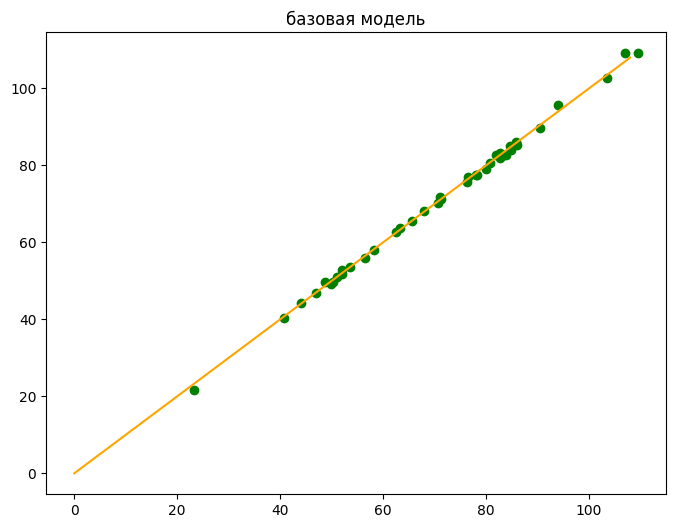

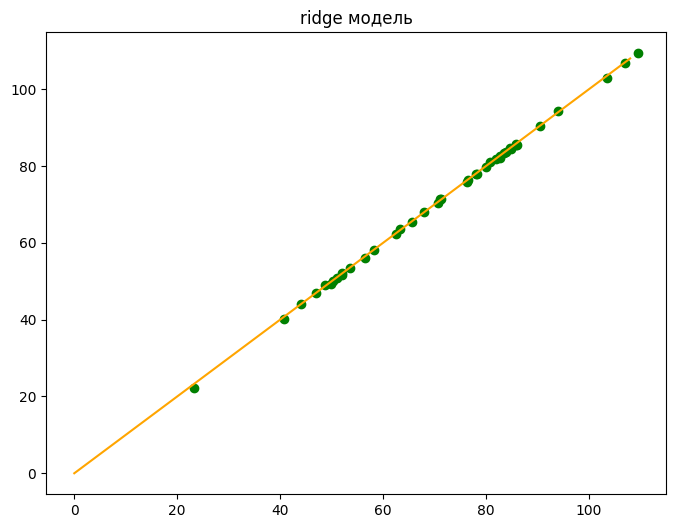

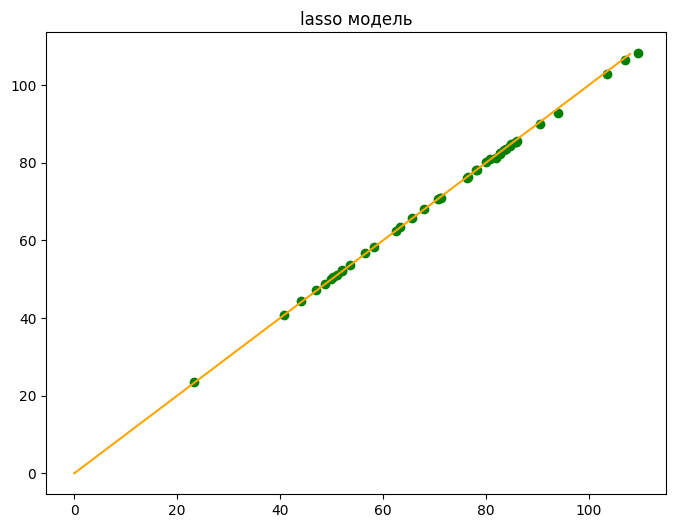

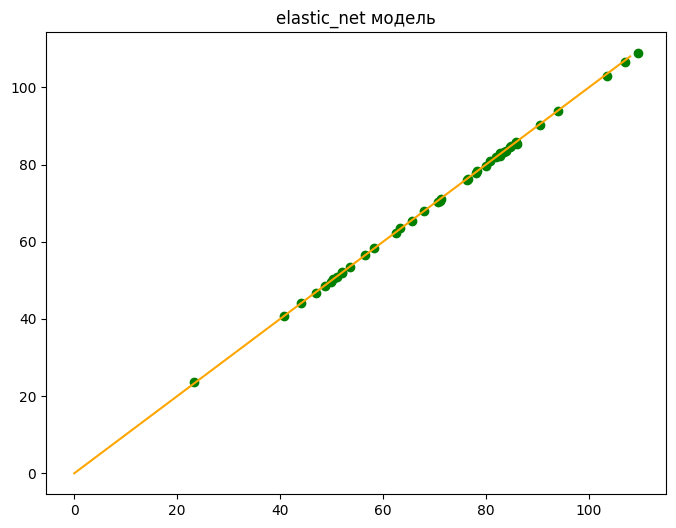

In [142]:
for i in range(len(all_names_models)):
    fig, axes = plt.subplots(figsize=(8, 6))
    plt.scatter([i for i in y_test], [i for i in all_models[i].predict(X_test)], label="линия 1", color = 'green')
    plt.plot(range(int(y_test.max())), range(int(y_test.max())), label="линия 2", color = 'orange')
    plt.title(all_names_models[i])



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [188]:
array_evaluation_metrics = ['R2', 'mse', 'rmse', 'mae']
new_df = pd.DataFrame(perfomance_metrics)
new_df.columns = array_evaluation_metrics
new_df["metric"] = [i.split()[0] for i in all_names_models]
print("Сортировка по наилучшему/наибольшему R2: ")
print(new_df.sort_values('R2', ascending=False)[['R2', "metric"]], '\n')
for i in array_evaluation_metrics[1:]:
    print("Сортировка по наилучшему/наименьшему", i, ':')
    print(new_df.sort_values(i, ascending=True)[[i, "metric"]], '\n')
print("Оптимальные гперпараметры для лучшей модели:", random_search_elastic.best_params_)

Сортировка по наилучшему/наибольшему R2: 
         R2       metric
3  0.999766  elastic_net
1  0.999701        ridge
2  0.999521        lasso
0  0.998412      базовая 

Сортировка по наилучшему/наименьшему mse :
        mse       metric
3  0.083716  elastic_net
1  0.106828        ridge
2  0.171497        lasso
0  0.568220      базовая 

Сортировка по наилучшему/наименьшему rmse :
       rmse       metric
3  0.289337  elastic_net
1  0.326846        ridge
2  0.414122        lasso
0  0.753804      базовая 

Сортировка по наилучшему/наименьшему mae :
        mae       metric
3  0.219088  elastic_net
1  0.266011        ridge
2  0.308600        lasso
0  0.594267      базовая 

Оптимальные гперпараметры для лучшей модели: {'l1_ratio': np.float64(0.9387755102040816), 'alpha': np.float64(1.2067926406393288)}


По всем четырем метрикам оценки выигрывает 3 моедель: elasticnet

---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


<Axes: >

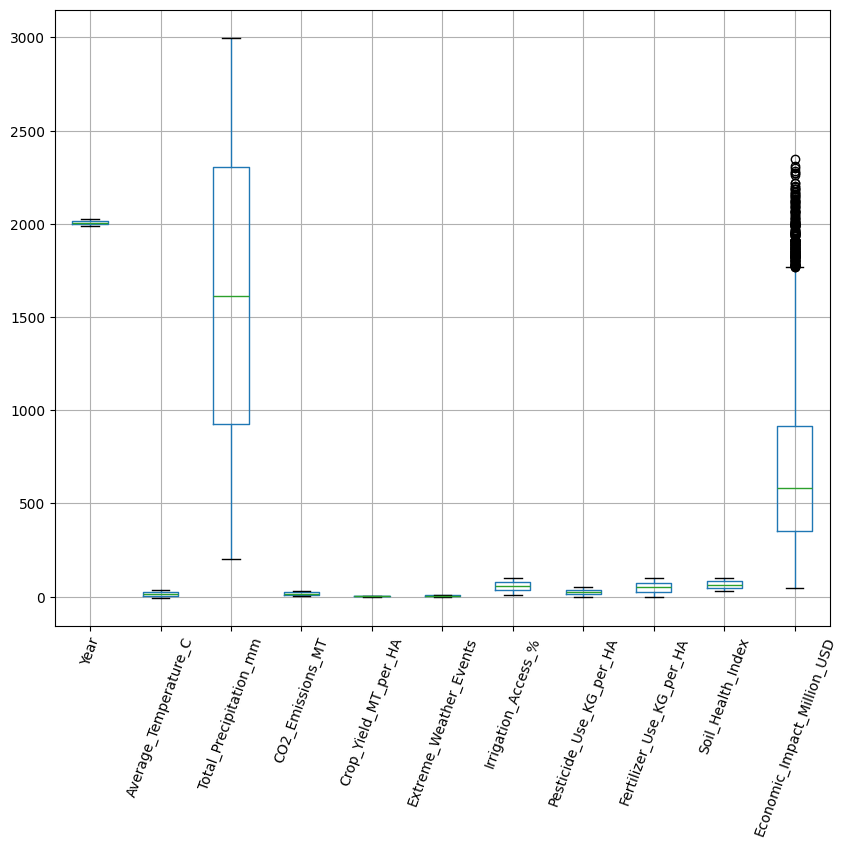

In [174]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('climate_change_impact_on_agriculture_2024.csv', sep = ',')
null_values = df.isnull().sum()
print(null_values)
fig, axes = plt.subplots(figsize=(10, 8))
df.boxplot(ax = axes, rot = 70)




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



Average_Temperature_C          float64
Total_Precipitation_mm         float64
CO2_Emissions_MT               float64
Crop_Yield_MT_per_HA           float64
Irrigation_Access_%            float64
Pesticide_Use_KG_per_HA        float64
Fertilizer_Use_KG_per_HA       float64
Soil_Health_Index              float64
Economic_Impact_Million_USD    float64
dtype: object


,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
Average_Temperature_C,1.000000,0.007213,-0.003052,0.263781,-0.013268,0.005764,-0.014725,-0.010841,0.195827
Total_Precipitation_mm,0.007213,1.000000,-0.008681,0.029728,-0.007580,0.011198,-0.026356,-0.021621,0.020966
CO2_Emissions_MT,-0.003052,-0.008681,1.000000,-0.089868,0.002995,0.015243,-0.020275,0.004518,-0.057035
Crop_Yield_MT_per_HA,0.263781,0.029728,-0.089868,1.000000,-0.000255,-0.004035,0.006423,-0.005692,0.726358
Irrigation_Access_%,-0.013268,-0.007580,0.002995,-0.000255,1.000000,-0.004588,0.008314,0.001652,0.003988
Pesticide_Use_KG_per_HA,0.005764,0.011198,0.015243,-0.004035,-0.004588,1.000000,-0.015429,0.012447,-0.007796
Fertilizer_Use_KG_per_HA,-0.014725,-0.026356,-0.020275,0.006423,0.008314,-0.015429,1.000000,-0.000125,0.010743
Soil_Health_Index,-0.010841,-0.021621,0.004518,-0.005692,0.001652,0.012447,-0.000125,1.000000,-0.000077
Economic_Impact_Million_USD,0.195827,0.020966,-0.057035,0.726358,0.003988,-0.007796,0.010743,-0.000077,1.000000


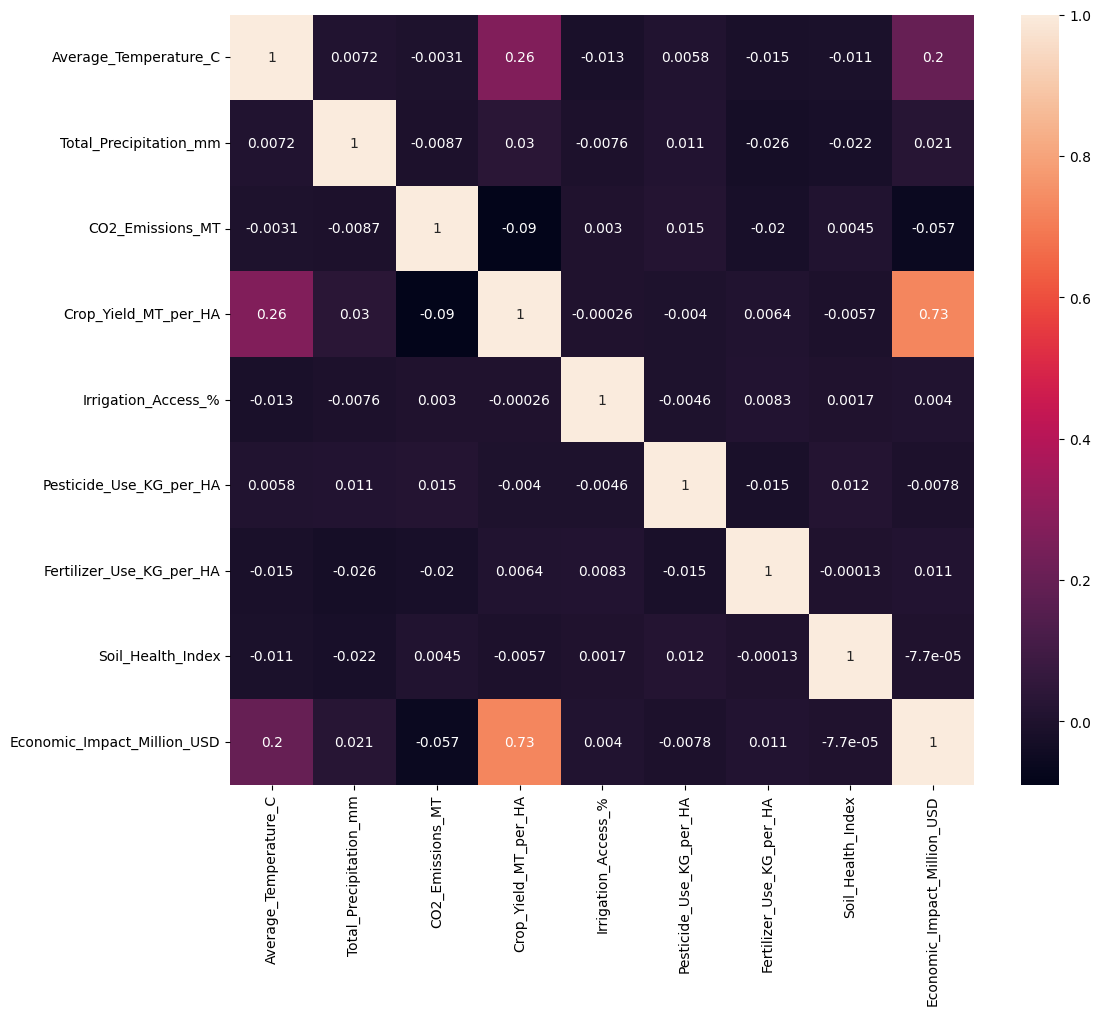

In [175]:
import seaborn as sns

numeric_df = df.select_dtypes(include='float64')
print(numeric_df.dtypes)

plt.figure(figsize=(12, 10))
sns.heatmap(data = numeric_df.corr(), annot=True)
numeric_df.corr()

In [176]:
df_1 = df[['Crop_Yield_MT_per_HA', 'Average_Temperature_C', 'Economic_Impact_Million_USD']]
df, df_1 = df_1, df


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [177]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [178]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

alpha = np.logspace(-4, 4, 50)
print("Значение альфа для всех видов моделей:", [f"{a:.2e}" for a in alpha], '\n\n\n')

param_alpha = {'alpha': alpha}
param_alpha_and_l1_ratio = {'alpha': alpha, 'l1_ratio': np.linspace(0, 1, 50)}

#БАЗОВАЯ МОДЕЛЬ
base_model = LinearRegression()
base_model.fit(X_train, y_train)

#RIDGE МОДЕЛЬ
random_search_ridge = RandomizedSearchCV(Ridge(), param_distributions=param_alpha, cv=5)
random_search_ridge.fit(X_train, y_train)

#LASSO МОДЕЛЬ
grid_search_lasso = GridSearchCV(Lasso(), param_grid=param_alpha, cv=5)
grid_search_lasso.fit(X_train, y_train)

#ELASTICNET МОДЕЛЬ
grid_search_elasticnet = GridSearchCV(ElasticNet(), param_grid=param_alpha_and_l1_ratio, cv=2)
grid_search_elasticnet.fit(X_train, y_train)



Значение альфа для всех видов моделей: ['1.00e-04', '1.46e-04', '2.12e-04', '3.09e-04', '4.50e-04', '6.55e-04', '9.54e-04', '1.39e-03', '2.02e-03', '2.95e-03', '4.29e-03', '6.25e-03', '9.10e-03', '1.33e-02', '1.93e-02', '2.81e-02', '4.09e-02', '5.96e-02', '8.69e-02', '1.26e-01', '1.84e-01', '2.68e-01', '3.91e-01', '5.69e-01', '8.29e-01', '1.21e+00', '1.76e+00', '2.56e+00', '3.73e+00', '5.43e+00', '7.91e+00', '1.15e+01', '1.68e+01', '2.44e+01', '3.56e+01', '5.18e+01', '7.54e+01', '1.10e+02', '1.60e+02', '2.33e+02', '3.39e+02', '4.94e+02', '7.20e+02', '1.05e+03', '1.53e+03', '2.22e+03', '3.24e+03', '4.71e+03', '6.87e+03', '1.00e+04'] 





/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.420e+08, tolerance: 5.980e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.420e+08, tolerance: 6.028e+04
Linear regression models with a zero l1 penalization strength are more efficiently fitted u

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([1.0000...00000000e+04]), 'l1_ratio': array([0. ..., 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [179]:
all_models = [base_model, random_search_ridge, grid_search_lasso, grid_search_elasticnet]
all_names_models = ['базовая модель', 'ridge модель', 'lasso модель', 'elastic_net модель']
array_evaluation_metrics = ['R2', 'mse', 'rmse', 'mae']

perfomance_metrics = []
for i in range(len(all_models)):
    r_2 = r2_score(y_true=y_test, y_pred=all_models[i].predict(X_test))
    mae = mean_absolute_error(y_true=y_test, y_pred=all_models[i].predict(X_test))
    mse = mean_squared_error(y_true=y_test, y_pred=all_models[i].predict(X_test))
    rmse = root_mean_squared_error(y_true=y_test, y_pred=all_models[i].predict(X_test))
    perfomance_metrics.append([r_2, mae, mse, rmse])
    print(f"{all_names_models[i]} показывает:")
    print(f"\tR_2_score = {r_2}")
    print(f"\tMAE = {mae}")
    print(f"\tMSE = {mse}")
    print(f'\tRMSE = {rmse}\n')


базовая модель показывает:
	R_2_score = 0.5290168593855393
	MAE = 224.95832238222255
	MSE = 81295.21903188336
	RMSE = 285.1231646707846

ridge модель показывает:
	R_2_score = 0.529018541211979
	MAE = 224.95831307174385
	MSE = 81294.92873603836
	RMSE = 285.1226555993725

lasso модель показывает:
	R_2_score = 0.5290193158630743
	MAE = 224.95800498255144
	MSE = 81294.79502545505
	RMSE = 285.1224211202182

elastic_net модель показывает:
	R_2_score = 0.5290321294895557
	MAE = 224.96051527644127
	MSE = 81292.583297515
	RMSE = 285.1185425354075





- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

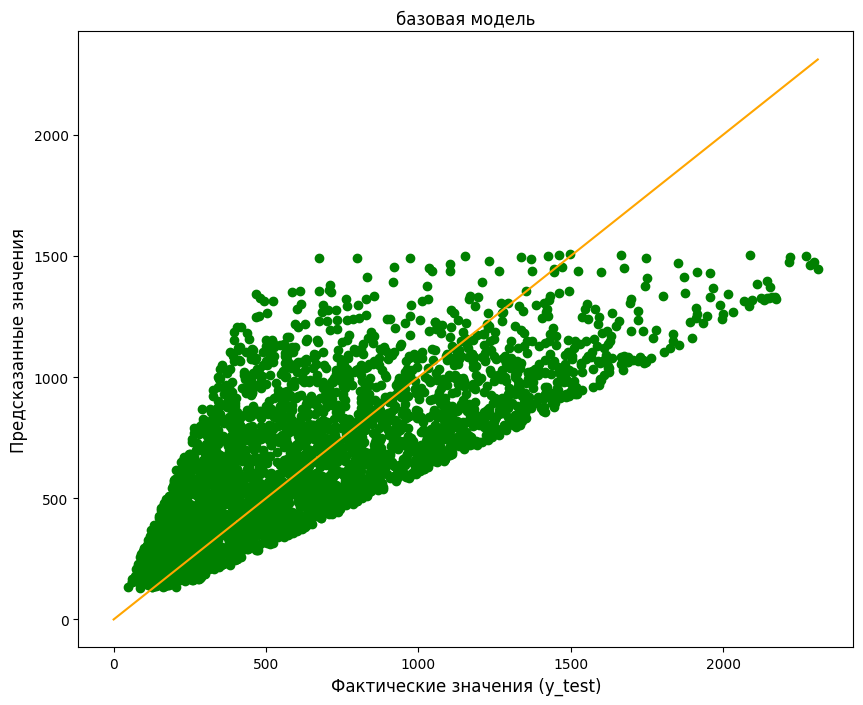

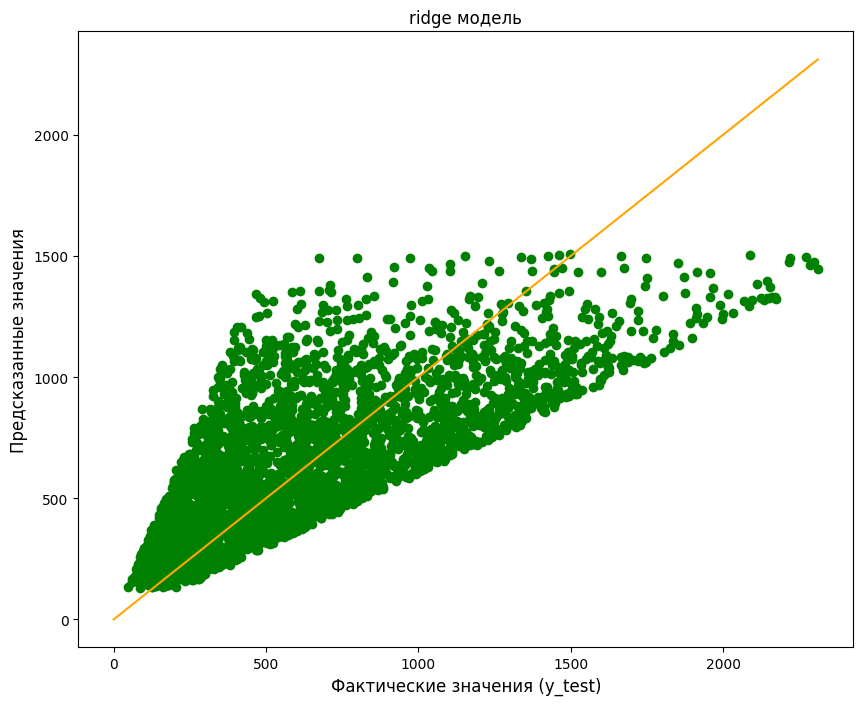

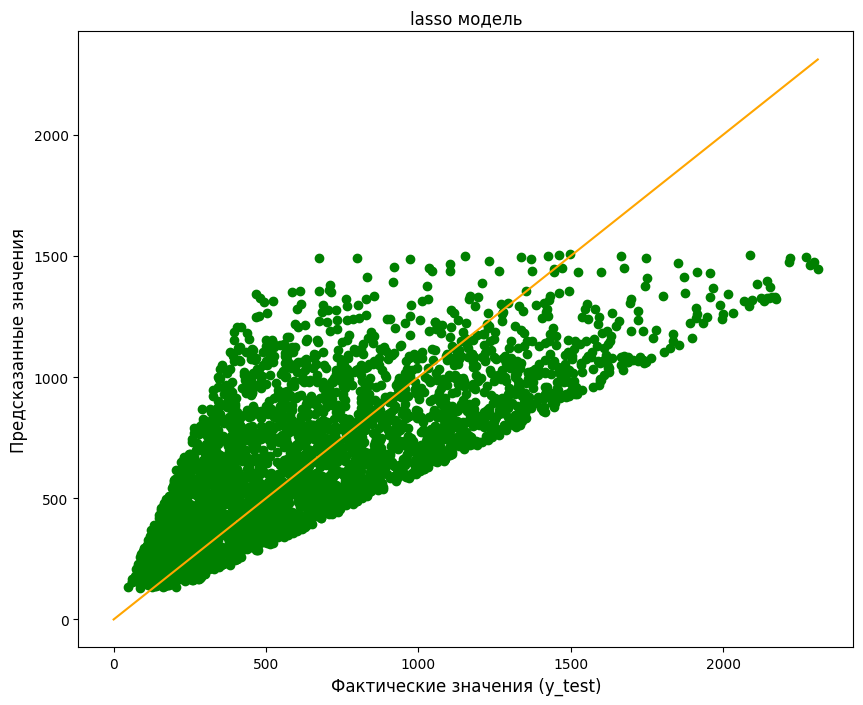

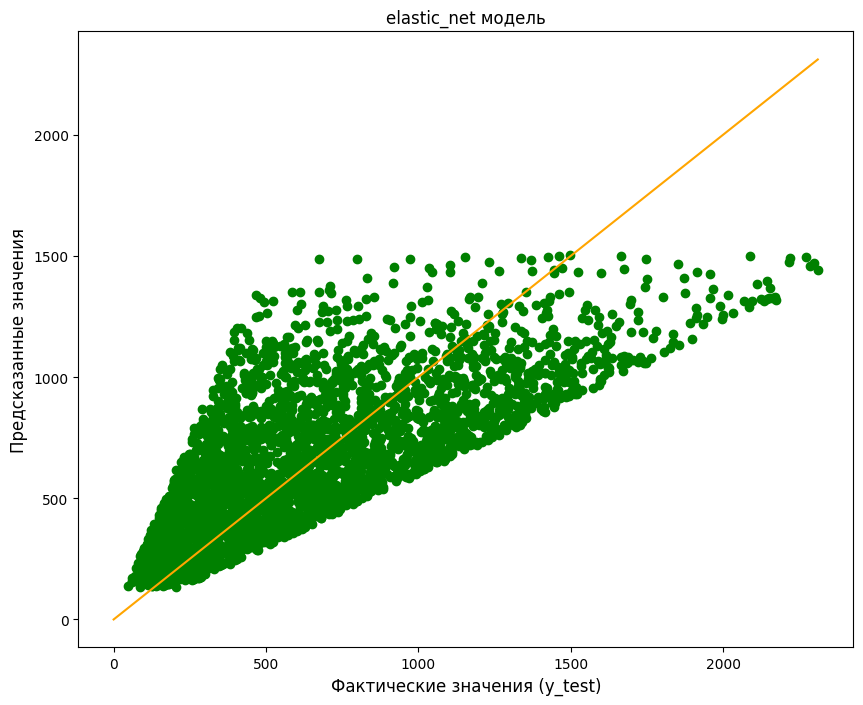

In [180]:
for i in range(len(all_names_models)):
    fig, axes = plt.subplots(figsize=(10, 8))
    plt.scatter([i for i in y_test], [i for i in all_models[i].predict(X_test)], color='green')
    plt.plot(range(int(y_test.max())), range(int(y_test.max())), color='orange')
    plt.title(all_names_models[i])
    axes.set_xlabel('Фактические значения (y_test)', fontsize=12)
    axes.set_ylabel('Предсказанные значения', fontsize=12)
    plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [181]:
new_df = pd.DataFrame(perfomance_metrics)
new_df.columns = array_evaluation_metrics
new_df['metric'] = [i.split()[0] for i in all_names_models]
print("Сортировка по лучшему/наибольшему R2: ")
print(new_df.sort_values('R2', ascending=False)[["R2", 'metric']], '\n')
for i in array_evaluation_metrics[1:]:
    print(f"Cортировка по лучшему {i}:")
    print(new_df.sort_values(i, ascending=True)[[i,'metric']], '\n')
print('Лучшая модель не имеет настравиваемы гиперпараметров')
df.index

Сортировка по лучшему/наибольшему R2: 
         R2       metric
3  0.529032  elastic_net
2  0.529019        lasso
1  0.529019        ridge
0  0.529017      базовая 

Cортировка по лучшему mse:
          mse       metric
2  224.958005        lasso
1  224.958313        ridge
0  224.958322      базовая
3  224.960515  elastic_net 

Cортировка по лучшему rmse:
           rmse       metric
3  81292.583298  elastic_net
2  81294.795025        lasso
1  81294.928736        ridge
0  81295.219032      базовая 

Cортировка по лучшему mae:
          mae       metric
3  285.118543  elastic_net
2  285.122421        lasso
1  285.122656        ridge
0  285.123165      базовая 

Лучшая модель не имеет настравиваемы гиперпараметров


RangeIndex(start=0, stop=10000, step=1)

- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



Crop_Yield_MT_per_HA : 301.55982736224087
Average_Temperature_C : 0.27418455279433274


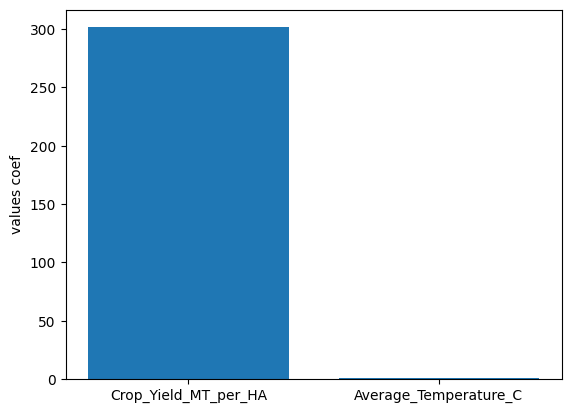

array([0.0229654])

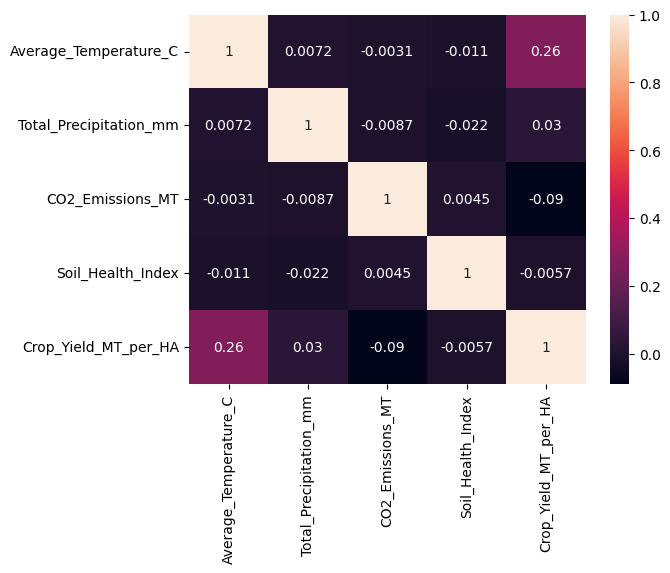

In [184]:
import math
print("Crop_Yield_MT_per_HA :", base_model.coef_[0])
print("Average_Temperature_C :", base_model.coef_[1])

plt.bar(['Crop_Yield_MT_per_HA', 'Average_Temperature_C'], [base_model.coef_[0], math.ceil(base_model.coef_[1])])
plt.ylabel('values coef')
plt.show()
df_for_influence = df_1[['Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Soil_Health_Index', 'Crop_Yield_MT_per_HA']]
sns.heatmap(df_for_influence.corr(), annot=True)

X = df[['Average_Temperature_C']]
y = df[['Crop_Yield_MT_per_HA']]

base_model_1 = LinearRegression()
base_model_1.fit(X, y)
base_model_1.coef_[0]

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: 'Average_Temperature_C': +0.26, 'Total_Precipitation_mm': +0.03
> - **Отрицательное влияние** на урожайность оказывают: 'CO2_Emissions_MT': -0.09, 'Soil_Health_Index': -0.0057
> - Наиболее значимым фактором является 'Average_Temperature_C' с коэффициентом +0.26, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на ~0.023 единиц.


---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


<Axes: >

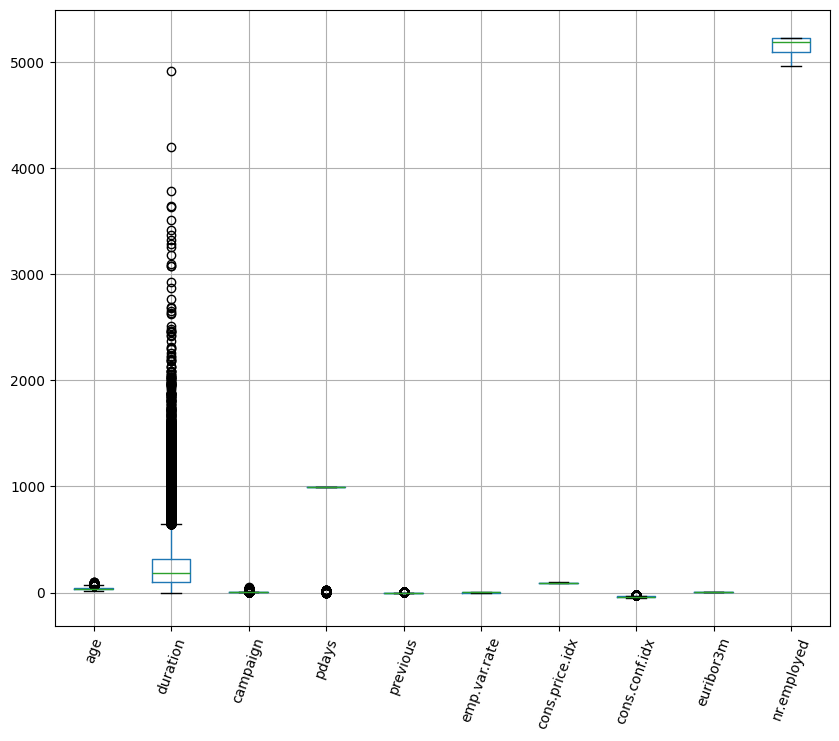

In [227]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
null_values = df.isnull().sum()
print(null_values)
fig, axes = plt.subplots(figsize=(10,8))
df.boxplot(ax=axes, rot=70)

In [228]:
df = df[df['duration'].between(0, 800)]
df = df[df['pdays'].between(800, 1300)]

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [229]:
df.shape

(37995, 21)

In [230]:
str_df = df.select_dtypes(include='string') 
df = pd.get_dummies(df, columns=str_df.columns, drop_first=True)
df.dtypes


age                                int64
duration                           int64
campaign                           int64
pdays                              int64
previous                           int64
emp.var.rate                     float64
cons.price.idx                   float64
cons.conf.idx                    float64
euribor3m                        float64
nr.employed                      float64
job_blue-collar                     bool
job_entrepreneur                    bool
job_housemaid                       bool
job_management                      bool
job_retired                         bool
job_self-employed                   bool
job_services                        bool
job_student                         bool
job_technician                      bool
job_unemployed                      bool
job_unknown                         bool
marital_married                     bool
marital_single                      bool
marital_unknown                     bool
education_basic.

In [243]:
set(df.dtypes)

{dtype('bool'), dtype('int64'), dtype('float64')}

In [247]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_df = df.select_dtypes(include=['int64', 'float64']) 
string_df = df.select_dtypes(include=['bool']) 
scaler_df = scaler.fit_transform(numeric_df)
new_df = pd.concat([pd.DataFrame(scaler_df, columns=numeric_df.columns, index=df.index), string_df], axis=1)
new_df



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,y_yes
0,1.573013,0.270088,-0.564962,0.0,-0.319460,0.611291,0.723007,0.923567,0.674803,0.278223,...,True,False,False,False,True,False,False,False,True,False
1,1.671116,-0.411707,-0.564962,0.0,-0.319460,0.611291,0.723007,0.923567,0.674803,0.278223,...,True,False,False,False,True,False,False,False,True,False
2,-0.290942,0.057027,-0.564962,0.0,-0.319460,0.611291,0.723007,0.923567,0.674803,0.278223,...,True,False,False,False,True,False,False,False,True,False
3,0.003367,-0.399532,-0.564962,0.0,-0.319460,0.611291,0.723007,0.923567,0.674803,0.278223,...,True,False,False,False,True,False,False,False,True,False
4,1.573013,0.550110,-0.564962,0.0,-0.319460,0.611291,0.723007,0.923567,0.674803,0.278223,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,3.240763,0.714472,-0.564962,0.0,-0.319460,-0.823395,2.083480,-2.263587,-1.597457,-3.088668,...,False,True,False,False,False,False,False,False,True,True
41184,0.591984,1.012757,-0.564962,0.0,-0.319460,-0.823395,2.083480,-2.263587,-1.597457,-3.088668,...,False,True,False,False,False,False,False,False,True,False
41185,1.573013,-0.168209,-0.211436,0.0,-0.319460,-0.823395,2.083480,-2.263587,-1.597457,-3.088668,...,False,True,False,False,False,False,False,False,True,False
41186,0.395779,1.371916,-0.564962,0.0,-0.319460,-0.823395,2.083480,-2.263587,-1.597457,-3.088668,...,False,True,False,False,False,False,False,False,True,True


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [248]:
X = new_df.iloc[:, 0:-1]
y = new_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


param = {"C": [0.1, 1, 10, 100]}
param_1 = {"C": [0.1, 1, 10, 100], 'l1_ratio': np.linspace(0, 1, 50)}

grid_search_l_2 = GridSearchCV(LogisticRegression(penalty='l2', max_iter=1000, random_state=42, class_weight='balanced'), param_grid=param, cv=5, n_jobs=-1)
grid_search_l_2.fit(X_train, y_train)

random_search_l_1 = RandomizedSearchCV(LogisticRegression(penalty='l1',solver='saga', random_state=42, max_iter=1000, class_weight='balanced'), param_distributions=param, cv=5, n_jobs=-1)
random_search_l_1.fit(X_train, y_train)

random_search_elastic_net = RandomizedSearchCV(LogisticRegression(penalty='elasticnet',solver='saga', random_state=42, max_iter=1000, class_weight='balanced'), param_distributions=param_1, cv=5, n_jobs=-1)
random_search_elastic_net.fit(X_train, y_train)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'l1_ratio': array([0. ..., 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [260]:
all_models = [grid_search_l_2, random_search_l_1, random_search_elastic_net]
all_name_models = ["LogisticRegression_L2", "LogisticRegression_L1", "ElasticNet"]



- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

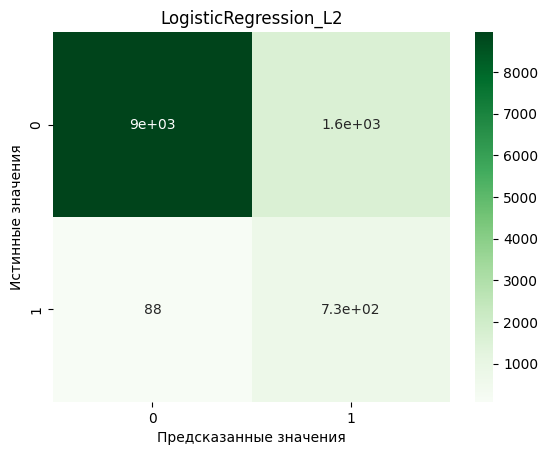

Все метрики оценки LogisticRegression_L2 модели:
LogisticRegression_L2 :
	- показывает accuracy оценку:  0.849548205982981
	- показывает recall оценку:  0.8922888616891065
	- показывает precision оценку: 0.3094227504244482
	- показывает f1 оуенку: 0.45950204853450993
[[8955 1627]
 [  88  729]]


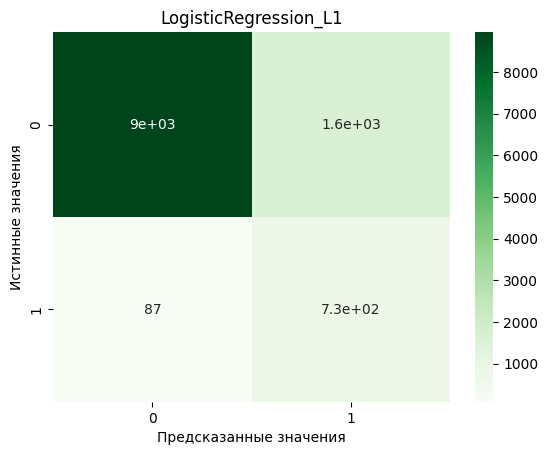

Все метрики оценки LogisticRegression_L1 модели:
LogisticRegression_L1 :
	- показывает accuracy оценку:  0.8497236599701729
	- показывает recall оценку:  0.8935128518971848
	- показывает precision оценку: 0.3098471986417657
	- показывает f1 оуенку: 0.4601323668452569
[[8956 1626]
 [  87  730]]


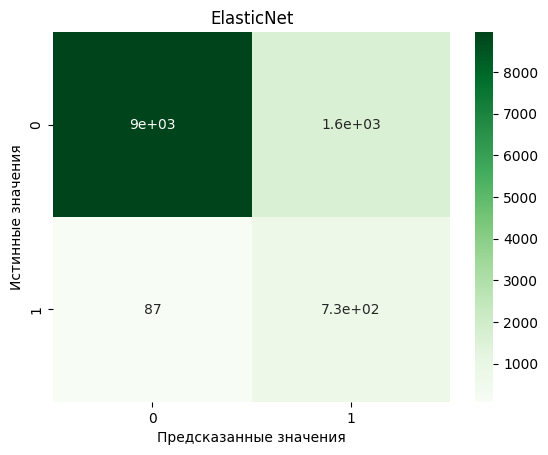

Все метрики оценки ElasticNet модели:
ElasticNet :
	- показывает accuracy оценку:  0.8497236599701729
	- показывает recall оценку:  0.8935128518971848
	- показывает precision оценку: 0.3098471986417657
	- показывает f1 оуенку: 0.4601323668452569
[[8956 1626]
 [  87  730]]


In [301]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

perfomance_metrics = []

for i in range(len(all_models)):
    accuracy = accuracy_score(y_test, all_models[i].predict(X_test))
    recall = recall_score(y_test, all_models[i].predict(X_test))
    precision = precision_score(y_test, all_models[i].predict(X_test))
    f1 = f1_score(y_test, all_models[i].predict(X_test))
    perfomance_metrics.append([accuracy, recall, precision,f1])
    cm = confusion_matrix(y_test, all_models[i].predict(X_test))
    sns.heatmap(cm, annot=True, cmap='Greens')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.title(f'{all_name_models[i]}')
    plt.show()
    print(f"Все метрики оценки {all_name_models[i]} модели:")
    print(all_name_models[i], ":")
    print("\t- показывает accuracy оценку: ", accuracy)
    print("\t- показывает recall оценку: ", recall)
    print('\t- показывает precision оценку:', precision)
    print("\t- показывает f1 оуенку:", f1)
    print(cm)



- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



Для LogisticRegression_L2 AUC равно: 0.9322763973926765
Для LogisticRegression_L1 AUC равно: 0.932282874755335
Для ElasticNet AUC равно: 0.9322791734052444


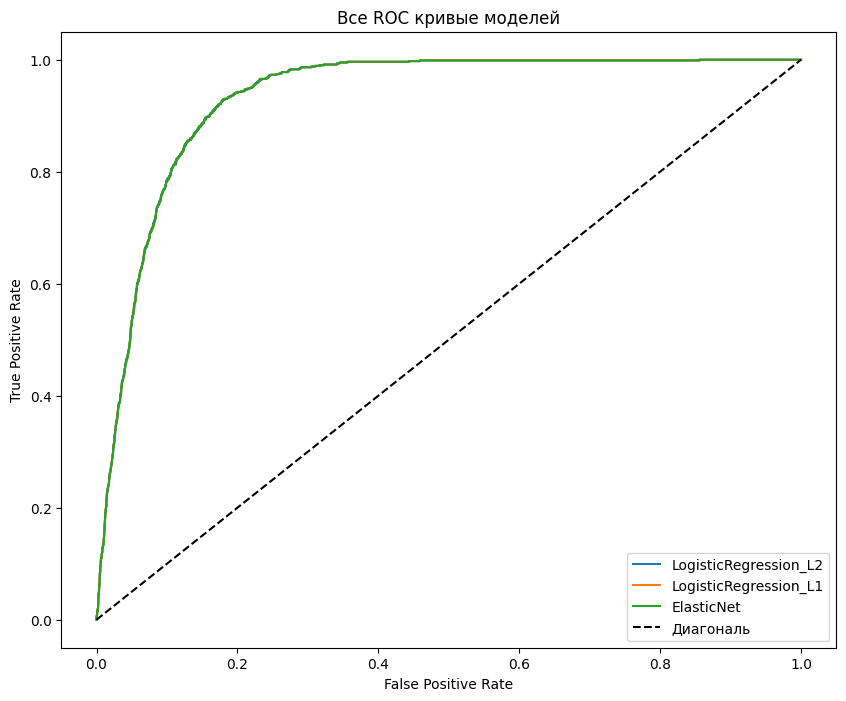

In [302]:
from sklearn.metrics import roc_curve, auc
fig, axes = plt.subplots(figsize=(10, 8))
for i in range(len(all_models)):
    fpr, tpr, _ = roc_curve(y_test, all_models[i].predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{all_name_models[i]}')
    print(f"Для {all_name_models[i]} AUC равно: {auc(fpr, tpr)}")
    perfomance_metrics[i].append(auc(fpr, tpr))
plt.plot([0, 1], [0, 1], 'k--', label='Диагональ')
plt.title(f"Все ROC кривые моделей")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [304]:
array_evaluation_metrics = ['accuracy', 'recall', 'precision', 'f1', 'auc']
new_df = pd.DataFrame(perfomance_metrics)
new_df.columns = array_evaluation_metrics
new_df["metric"] = [i for i in all_name_models]
for i in array_evaluation_metrics:
    print("Сортировка по наилучшему/наибольшему", i, ':')
    print(new_df.sort_values(i, ascending=False)[[i, "metric"]], '\n')


Сортировка по наилучшему/наибольшему accuracy :
   accuracy                 metric
1  0.849724  LogisticRegression_L1
2  0.849724             ElasticNet
0  0.849548  LogisticRegression_L2 

Сортировка по наилучшему/наибольшему recall :
     recall                 metric
1  0.893513  LogisticRegression_L1
2  0.893513             ElasticNet
0  0.892289  LogisticRegression_L2 

Сортировка по наилучшему/наибольшему precision :
   precision                 metric
1   0.309847  LogisticRegression_L1
2   0.309847             ElasticNet
0   0.309423  LogisticRegression_L2 

Сортировка по наилучшему/наибольшему f1 :
         f1                 metric
1  0.460132  LogisticRegression_L1
2  0.460132             ElasticNet
0  0.459502  LogisticRegression_L2 

Сортировка по наилучшему/наибольшему auc :
        auc                 metric
1  0.932283  LogisticRegression_L1
2  0.932279             ElasticNet
0  0.932276  LogisticRegression_L2 

{'C': 1}


In [306]:
print(f"Лучший гиперпараметр 'С' для LogisticRegression_L1: {random_search_l_1.best_params_['C']}")

Лучший гиперпараметр 'С' для LogisticRegression_L1: 1
